## LangGraph tool-node, conditional-edge, loop

### Instalacja bibliotek

In [3]:
!pip install -q langgraph langchain langchain-openai python-dotenv
!apt install libgraphviz-dev
!pip install pygraphviz

Error: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
Error: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

load_dotenv()

# Model LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


### Definicja stanu

In [5]:
class State(TypedDict):
    question: str
    llm_answer: str
    is_correct: bool


### Węzeł LLM

In [6]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "Jesteś pomocnym asystentem matematycznym. Odpowiadaj tylko wynikiem liczbowym."),
    ("user", "{question}")
])

def ask_llm(state: State) -> State:
    response = (prompt | llm).invoke({"question": state["question"]})
    return {"llm_answer": response.content, "is_correct": False}

### Węzeł z narzędziem

In [12]:
def tool_calc(state: State) -> State:
    try:
        correct = eval(state["question"])
        user_answer = int(state["llm_answer"])
        return {"is_correct": (correct == user_answer)}
    except Exception:
        return {"is_correct": False}


### Węzeł końcowy

In [13]:
def finish(state: State) -> State:
    if state["is_correct"]:
        print(f"✅ Poprawna odpowiedź: {state['llm_answer']}")
    else:
        print("❌ Nie udało się uzyskać poprawnej odpowiedzi.")
    return state


### Uruchomienie grafu

In [9]:
graph = StateGraph(State)

graph.add_node("ask_llm", ask_llm)
graph.add_node("tool_calc", tool_calc)
graph.add_node("finish", finish)

graph.set_entry_point("ask_llm")
graph.add_edge("ask_llm", "tool_calc")

# Warunek: jeśli poprawna -> finish, jeśli nie -> znowu ask_llm
def check_answer(state: State):
    return "finish" if state["is_correct"] else "ask_llm"

graph.add_conditional_edges("tool_calc", check_answer, ["finish", "ask_llm"])
graph.add_edge("finish", END)

app = graph.compile(debug=True)

In [10]:
app.invoke({"question": "2 * 15"})

[values] {'question': '2 * 15'}
[updates] {'ask_llm': {'llm_answer': '30', 'is_correct': False}}
[values] {'question': '2 * 15', 'llm_answer': '30', 'is_correct': False}
[updates] {'tool_calc': {'is_correct': True}}
[values] {'question': '2 * 15', 'llm_answer': '30', 'is_correct': True}
✅ Poprawna odpowiedź: 30
[updates] {'finish': {'question': '2 * 15', 'llm_answer': '30', 'is_correct': True}}
[values] {'question': '2 * 15', 'llm_answer': '30', 'is_correct': True}


{'question': '2 * 15', 'llm_answer': '30', 'is_correct': True}

### Wizualizacja grafu

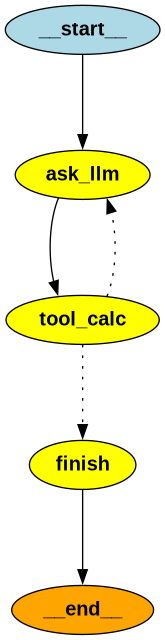

In [11]:
from IPython.display import Image, display

png_bytes = app.get_graph().draw_png()
display(Image(png_bytes))